In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"


df = pd.read_csv(url,names=column_names,na_values="?",comment='\t',sep=r'\s+',skipinitialspace=True)

display(df.head(35))
display(df.shape)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


(398, 9)

In [33]:
df.info()
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB




,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [34]:
print(df.isna().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [35]:
outliers = df[df['horsepower'] > 202.5]
outliers[['car_name', 'horsepower', 'cylinders']]

,car_name,horsepower,cylinders
6,chevrolet impala,220.0,8
7,plymouth fury iii,215.0,8
8,pontiac catalina,225.0,8
13,buick estate wagon (sw),225.0,8
25,ford f250,215.0,8
27,dodge d200,210.0,8
67,mercury marquis,208.0,8
94,chrysler new yorker brougham,215.0,8
95,buick electra 225 custom,225.0,8
116,pontiac grand prix,230.0,8


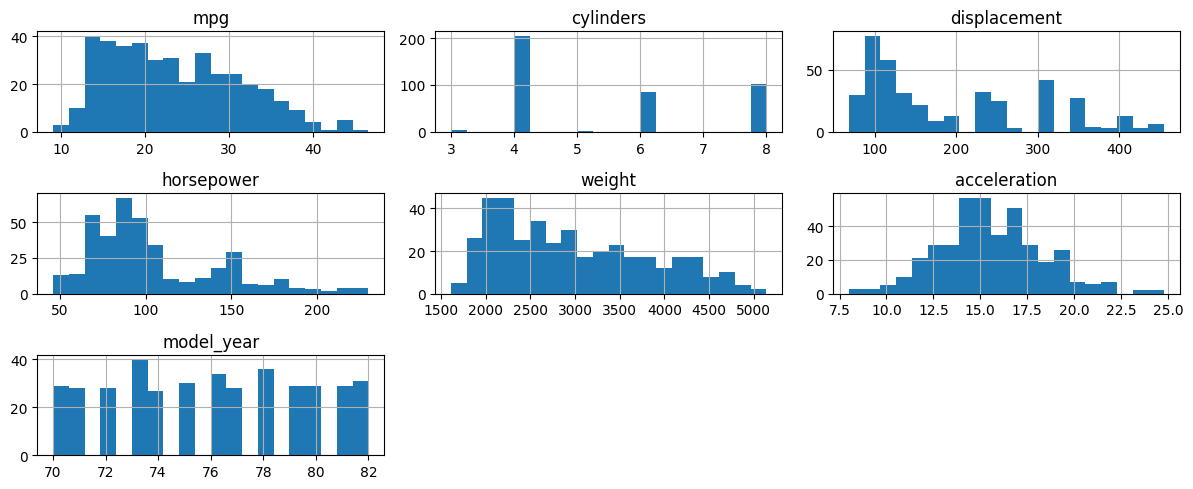

In [36]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

df[numeric_cols].hist(figsize=(12,5),bins=20)
plt.tight_layout()
plt.savefig("../images/histograms_analysis.png",dpi=150)
plt.show()

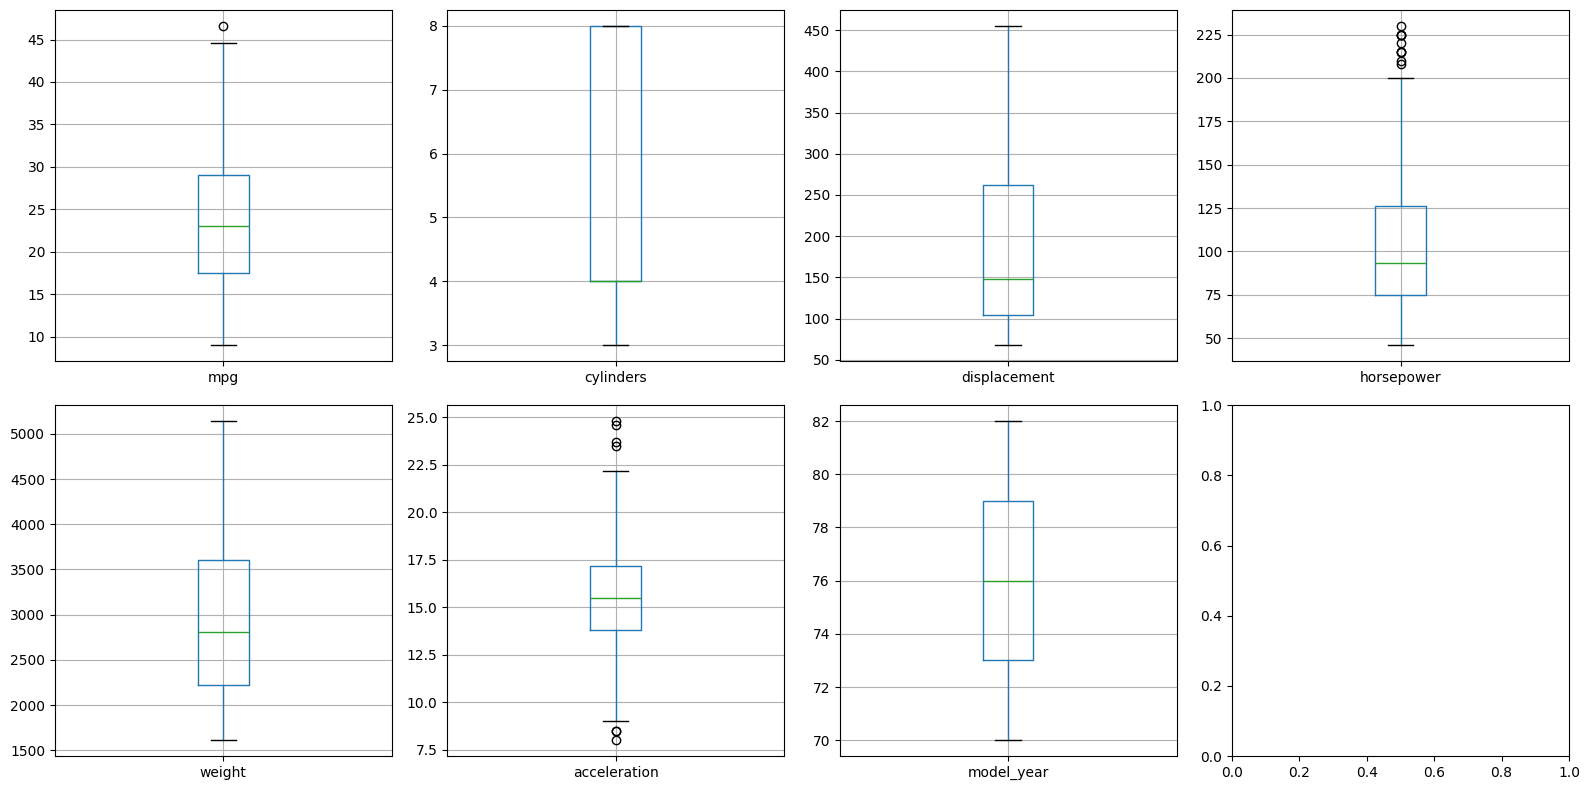

In [37]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[i])

plt.tight_layout()
plt.savefig("../images/boxplots_analysis.png",dpi=150)
plt.show()

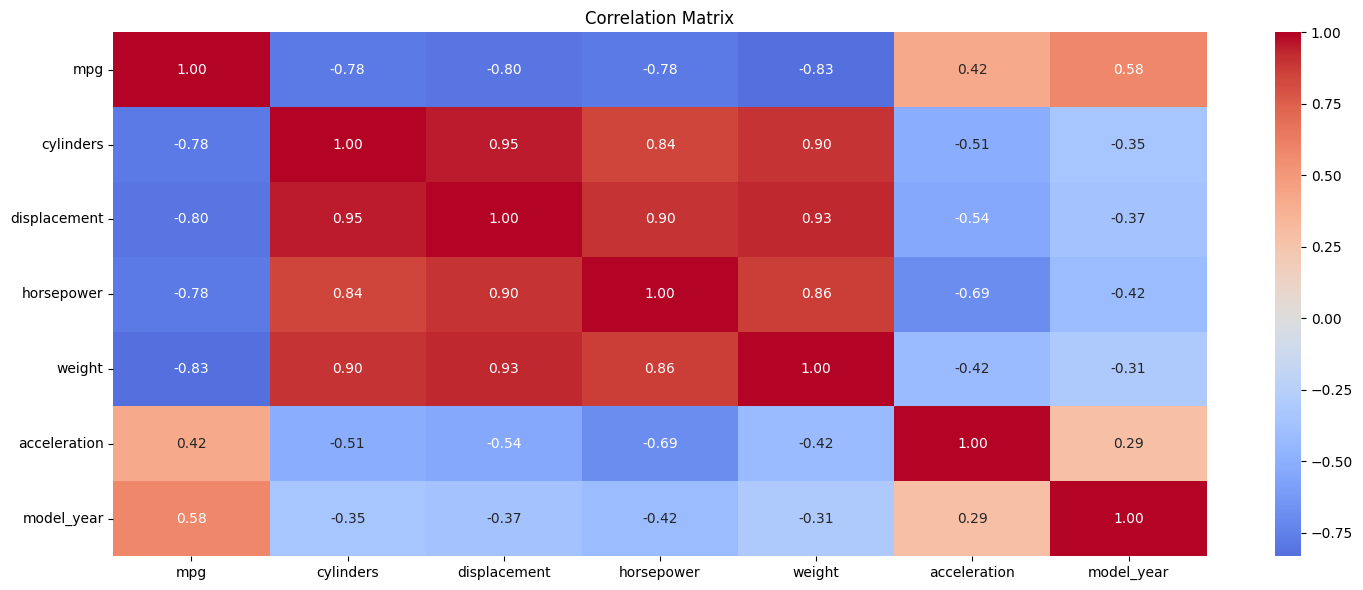

In [38]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(15,6))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title("Correlation Matrix")
plt.savefig("../images/correlation_analysis.png",dpi=150)
plt.tight_layout()

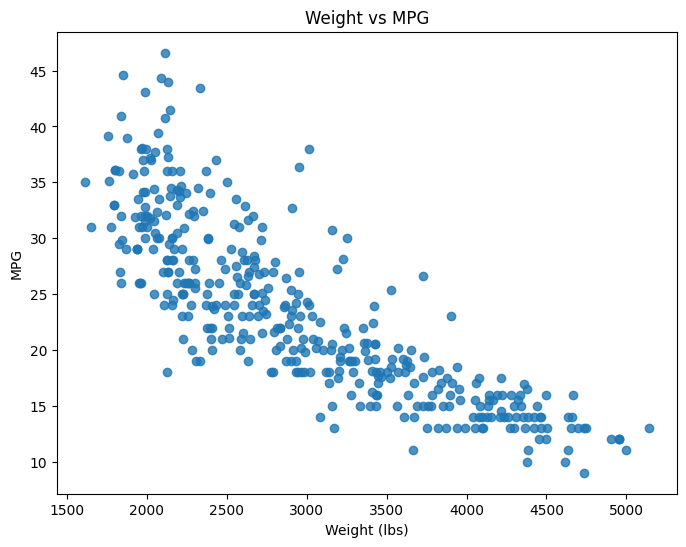

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(df['weight'], df['mpg'], alpha=0.8)
plt.xlabel('Weight (lbs)')
plt.ylabel('MPG')
plt.title('Weight vs MPG')
plt.savefig("../images/weight_mpg_scatter_correlation.png",dpi=150)
plt.show()

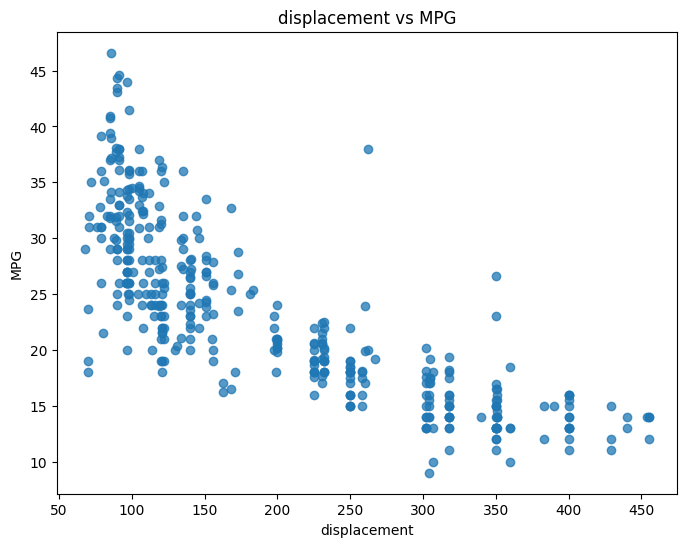

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(df['displacement'],df['mpg'],alpha=0.75)
plt.xlabel('displacement')
plt.ylabel('MPG')
plt.title('displacement vs MPG')
plt.show()

In [41]:
df[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


In [42]:
df_clean = df.dropna(subset=["horsepower"])

In [43]:
print(f"Filas originales: {df.shape[0]}")
print(f"Filas después de dropna: {df_clean.shape[0]}")
print(f"Nulos restantes en horsepower: {df_clean['horsepower'].isna().sum()}")

Filas originales: 398
Filas después de dropna: 392
Nulos restantes en horsepower: 0


In [44]:
df.to_csv("../datasets/raw/data_raw.csv", index=False)

In [45]:
df_clean.to_csv("../datasets/preprocess/data_processed.csv",index=False)

In [46]:
from sklearn.model_selection import train_test_split


X_simple = df_clean[['weight']]
y = df_clean['mpg']

X_train_simple,X_test_simple,y_train,y_test = train_test_split(X_simple,y,test_size=0.2,random_state=42)

print(f"Train: {X_train_simple.shape[0]} rows")
print(f"Test: {X_test_simple.shape[0]} rows")


Train: 313 rows
Test: 79 rows


In [47]:
X_multiple = df_clean[['horsepower', 'model_year', 'acceleration']]

X_train_multiple, X_test_multiple, y_train, y_test = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

scores_simple = cross_val_score(LinearRegression(),X_train_simple,y_train,cv=5,scoring='r2')

scores_multiple = cross_val_score(LinearRegression(),X_train_multiple,y_train,cv=5,scoring='r2')

print("Model 1 (weight) - R² by fold:", scores_simple)
print("Model 1 - R² mean:", scores_simple.mean(), "± ", scores_simple.std())

print("\nModel 2 (horsepower, model_year, acceleration) - R² by fold:", scores_multiple)
print("Model 2 - R² mean:", scores_multiple.mean(), "± ", scores_multiple.std())



Model 1 (weight) - R² by fold: [0.67708026 0.65510099 0.65477784 0.77760415 0.71619461]
Model 1 - R² mean: 0.6961515685162952 ±  0.04646912282533653

Model 2 (horsepower, model_year, acceleration) - R² by fold: [0.68669964 0.73411543 0.65613036 0.73639309 0.68156602]
Model 2 - R² mean: 0.6989809083801879 ±  0.03138274395462184


In [49]:
#MLFLOW SETUP
import mlflow
import mlflow.sklearn

mlflow.set_experiment("mpg-regression")

<Experiment: artifact_location='file:///c:/Users/sgfar/anaconda_projects/PythonJupyterProject/MPGDataset/notebooks/mlruns/420855907738799431', creation_time=1785016613456, experiment_id='420855907738799431', last_update_time=1785016613456, lifecycle_stage='active', name='mpg-regression', tags={}>

In [50]:
from sklearn.metrics import root_mean_squared_error,r2_score,mean_squared_error
import numpy as np


with mlflow.start_run(run_name='mode_1_weight'):
    model_simple = LinearRegression()

    cv_scores = cross_val_score(model_simple,X_train_simple,y_train,cv=5,scoring='r2')

    model_simple.fit(X_train_simple,y_train)

    y_pred_simple = model_simple.predict(X_test_simple)

    r2_simple = r2_score(y_test,y_pred_simple)
    rmse_simple = root_mean_squared_error(y_test,y_pred_simple)

    mlflow.log_param("feature","weight")
    mlflow.log_metric("cv_r2_mean",cv_scores.mean())
    mlflow.log_metric("cv_r2_std",cv_scores.std())
    mlflow.log_metric("test_r2",r2_simple)
    mlflow.log_metric("test_rmse",rmse_simple)
    


    mlflow.sklearn.log_model(model_simple,"model")



    print("MODEL 1 (weight)")
    print(f"CV R2: {cv_scores}")
    print(f"CV R2 Mean: {cv_scores.mean()}")
    print(f"CV R2 STD: {cv_scores.std()}")
    print("-"*15)
    print(f"R² on test: {r2_simple:.4f}")
    print(f"RMSE on test: {rmse_simple:.4f}")
    print(f"Coeficient (slope): {model_simple.coef_[0]:.4f}")
    print(f"Intercept: {model_simple.intercept_:.4f}")


MODEL 1 (weight)
CV R2: [0.67708026 0.65510099 0.65477784 0.77760415 0.71619461]
CV R2 Mean: 0.6961515685162952
CV R2 STD: 0.04646912282533653
---------------
R² on test: 0.6533
RMSE on test: 4.2064
Coeficient (slope): -0.0079
Intercept: 47.2005


In [51]:
with mlflow.start_run(run_name='mode_2_multiple'):    
    model_multiple = LinearRegression()

    cv_scores = cross_val_score(model_multiple,X_train_multiple,y_train,cv=5,scoring='r2')

    model_multiple.fit(X_train_multiple, y_train)

    y_pred_multiple = model_multiple.predict(X_test_multiple)

    r2_multiple = r2_score(y_test, y_pred_multiple)
    rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))


    mlflow.log_param("features", "horsepower, model_year, acceleration")

    
    mlflow.log_metrics({
        "cv_r2_mean": cv_scores.mean(),
        "cv_r2_std": cv_scores.std(),
        "test_r2": r2_multiple,
        "test_rmse": rmse_multiple
    })

    mlflow.sklearn.log_model(model_multiple,"multiple_model")

    print("MODEL 2 (horsepower, model_year, acceleration)")
    print(f"R² en test: {r2_multiple:.4f}")
    print(f"RMSE en test: {rmse_multiple:.4f}")
    print("Coeficientes:", dict(zip(X_multiple.columns, model_multiple.coef_)))
    print(f"Intercepto: {model_multiple.intercept_:.4f}")

MODEL 2 (horsepower, model_year, acceleration)
R² en test: 0.6780
RMSE en test: 4.0540
Coeficientes: {'horsepower': -0.16817858526493742, 'model_year': 0.6658313728403406, 'acceleration': -0.6633015153822948}
Intercepto: 0.7588


In [52]:
X_multiple_v2 = df_clean[['weight', 'model_year', 'acceleration']]


X_train_multiple_v2,X_test_multiple_v2,y_train,y_test = train_test_split(X_multiple_v2,y,test_size=0.2,random_state=42)

In [54]:
#SETUO MLFLOW TRACKING FOR MULTIPLE FEATURES V2
with mlflow.start_run(run_name="model_multiple_v2_weight"):
    model_v2 = LinearRegression()

    cv_scores = cross_val_score(model_v2,X_train_multiple_v2,y_train,cv=5,scoring='r2')

    model_v2.fit(X_train_multiple_v2,y_train)


    y_pred = model_v2.predict(X_test_multiple_v2)

    r2_score_v2 = r2_score(y_test,y_pred)
    rmse_score_v2 = root_mean_squared_error(y_test,y_pred)

    mlflow.log_param("features","weight, model_year, acceleration")

    mlflow.log_metrics({
            "cv_r2_mean": cv_scores.mean(),
            "cv_r2_std": cv_scores.std(),
            "r2_score": r2_score_v2,
            "rmse_score": rmse_score_v2
        })

    mlflow.sklearn.log_model(model_v2,"model")

    
    print("MODEL 3 (weight, model_year, acceleration)")
    print(f"R² on test: {r2_score_v2:.4f}")
    print(f"RMSE on test: {rmse_score_v2:.4f}")
    print("Coeficients:", dict(zip(X_multiple_v2.columns, model_v2.coef_)))
    print(f"Intercept: {model_v2.intercept_:.4f}")
    print("-"*15)
    print(f"CV R2 scores: {cv_scores}")
    print(f"CV r2 mean: {cv_scores.mean()} - CV r2 std: {cv_scores.std()}")


MODEL 3 (weight, model_year, acceleration)
R² on test: 0.7936
RMSE on test: 3.2456
Coeficients: {'weight': -0.006717118244645066, 'model_year': 0.7643720470632753, 'acceleration': 0.07780752602952085}
Intercept: -15.8029
---------------
CV R2 scores: [0.81599909 0.78350917 0.75374858 0.79075843 0.85133591]
CV r2 mean: 0.7990702354528703 - CV r2 std: 0.0328133259679189


In [57]:
residuals = y_test - y_pred

print(residuals.describe())

count    79.000000
mean     -0.179922
std       3.261359
min      -8.779457
25%      -2.089777
50%       0.012042
75%       2.128685
max       9.517834
Name: mpg, dtype: float64


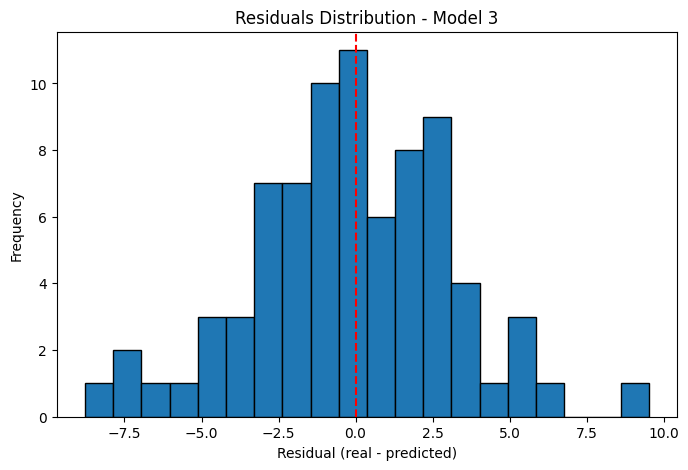

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residual (real - predicted)')
plt.ylabel('Frequency')
plt.title('Residuals Distribution - Model 3')
plt.axvline(0, color='red', linestyle='--')
plt.savefig("../images/residuals_histogram.png",dpi=100)
plt.show()

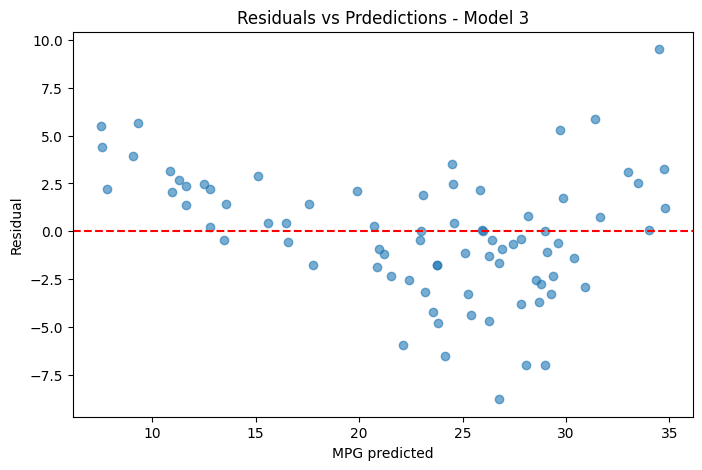

In [64]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('MPG predicted')
plt.ylabel('Residual')
plt.title('Residuals vs Prdedictions - Model 3')
plt.savefig("../images/residuals_scatter.png",dpi=100)
plt.show()

In [70]:
#Fast prediction with Synthethic data


synthetic_car =  pd.DataFrame({
    'weight': [3200,4500],        
    'model_year': [80,70],      
    'acceleration': [16.5,20]   
})

predictions = model_v2.predict(synthetic_car)


for i,pred in enumerate(predictions):
    print(f"Car {i+1} -> MPG predicted: {pred:.2f}")

#print(f"MPG predicted for this car: {prediction[0]:.2f}")

Car 1 -> MPG predicted: 25.14
Car 2 -> MPG predicted: 9.03


In [71]:
# The "weights" (coeficients) - one by each feature
pesos = dict(zip(X_multiple_v2.columns, model_v2.coef_))

# "bias" (intercept)
bias = model_v2.intercept_

print("Weights (coeficients):")
for feature, peso in pesos.items():
    print(f"  {feature}: {peso:.4f}")

print(f"\nBias (intercept): {bias:.4f}")

Weights (coeficients):
  weight: -0.0067
  model_year: 0.7644
  acceleration: 0.0778

Bias (intercept): -15.8029
